# Anforderungen an Projektumsetzung: Clustering

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



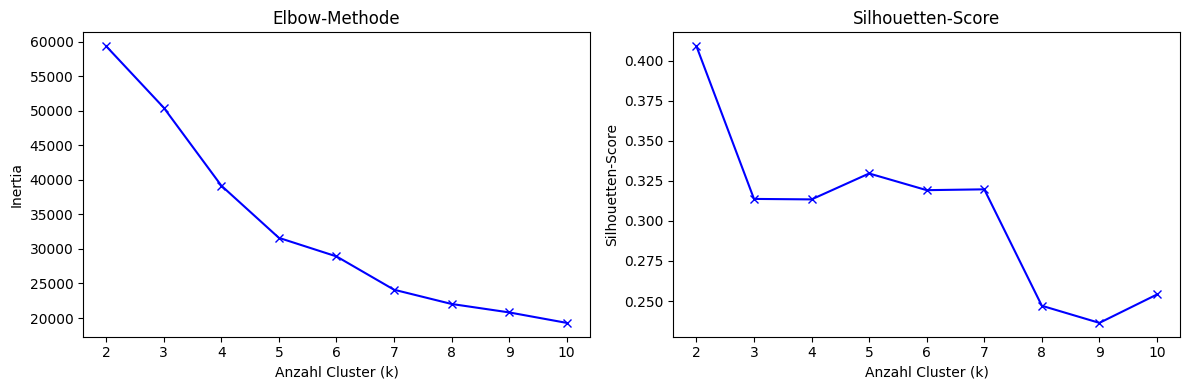

Optimale Clusteranzahl: 2


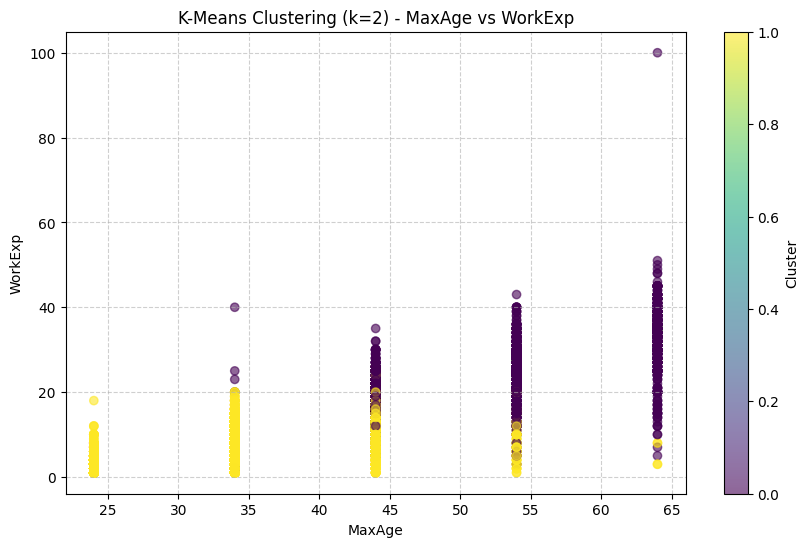


Cluster-Statistiken:
         MaxAge  YearsCode  WorkExp  JobSat  ConvertedCompYearly
Cluster                                                         
0         51.15      29.31    23.42    7.45            140031.16
1         35.48      11.87     7.73    7.05             81140.78


/var/folders/dr/lf4__k395mg4yymndm95cms00000gn/T/ipykernel_39010/4177059601.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = clusters


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Daten mit spezifischen Spalten laden
columns_to_use = ['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']
df = pd.read_csv("survey_results_shortened.csv", usecols=columns_to_use)

# 2. Fehlende Werte behandeln
df_clean = df.dropna()  # Oder geeignete Imputation

# 3. Daten skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# 4. Beste Clusteranzahl finden
K = range(2, 11)
inertias = []
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# 5. Elbow- und Silhouetten-Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.title('Elbow-Methode')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'bx-')
plt.title('Silhouetten-Score')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Silhouetten-Score')

plt.tight_layout()
plt.show()

# 6. Bestes k basierend auf Silhouetten-Score
best_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimale Clusteranzahl: {best_k}")

# 7. Finales Modell
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = final_kmeans.fit_predict(X_scaled)

# 8. Visualisierung mit MaxAge und WorkExp
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['MaxAge'], 
                     df_clean['WorkExp'], 
                     c=clusters, 
                     cmap='viridis',
                     alpha=0.6)
plt.xlabel('MaxAge')
plt.ylabel('WorkExp')
plt.title(f'K-Means Clustering (k={best_k}) - MaxAge vs WorkExp')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 9. Cluster-Statistiken
df_clean['Cluster'] = clusters
print("\nCluster-Statistiken:")
print(df_clean.groupby('Cluster')[columns_to_use].mean().round(2))

In [ ]:
from kmodes.kprototypes import KPrototypes
import pandas as pd
import numpy as np

# Daten laden
df = pd.read_csv("stack-overflow-developer-survey-2025/survey_results_public_without_SO.csv")

# Numerische und kategorische Spalten identifizieren
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Fehlende Werte behandeln
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())
df[categorical_columns] = df[categorical_columns].fillna('Unknown')

# Kategorische Spalten in numerische Codes umwandeln
for col in categorical_columns:
    df[col] = df[col].astype('category').cat.codes.astype('int')  # Explizit in int umwandeln

# Indizes der kategorialen Spalten (die ersten len(categorical_columns) Spalten)
categorical_indices = list(range(len(categorical_columns)))

# K-Prototypes Modell
kproto = KPrototypes(n_clusters=3, init='Huang', random_state=42)
clusters = kproto.fit_predict(df.values, categorical=categorical_indices)

# Ergebnisse zum DataFrame hinzufügen
df['Cluster'] = clusters

# Anzahl der Datenpunkte pro Cluster anzeigen
print("Anzahl der Datenpunkte pro Cluster:")
print(df['Cluster'].value_counts().sort_index())

# Einfache Visualisierung (nur für numerische Spalten)
if len(numerical_columns) >= 2:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.scatter(df[numerical_columns[0]], 
                df[numerical_columns[1]], 
                c=df['Cluster'], 
                cmap='viridis',
                alpha=0.6)
    plt.xlabel(numerical_columns[0])
    plt.ylabel(numerical_columns[1])
    plt.title('K-Prototypes Clustering')
    plt.colorbar(label='Cluster')
    plt.show()

AssertionError: The 'categorical'                 argument needs to be an integer with the index of the categorical                 column in your data, or a list or tuple of several of them,                 but it is a <class 'range'>.